In [81]:
# Importación de Librerías
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from wordcloud import WordCloud
import os
import re




%matplotlib inline
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = [12.0, 8.0]

In [56]:
dataset= pd.read_csv("input/petfinder-adoption-prediction/train/train.csv")
print("Directorio actual:", os.getcwd())
dataset.head(20)
print("Número de filas y columnas:", dataset.shape)

Directorio actual: c:\Users\Gloria\Documents\AUSTRAL\LAB2\UA_MDM_Labo2_Grupo12
Número de filas y columnas: (14993, 24)


In [57]:
dataset.dtypes

Type               int64
Name              object
Age                int64
Breed1             int64
Breed2             int64
Gender             int64
Color1             int64
Color2             int64
Color3             int64
MaturitySize       int64
FurLength          int64
Vaccinated         int64
Dewormed           int64
Sterilized         int64
Health             int64
Quantity           int64
Fee                int64
State              int64
RescuerID         object
VideoAmt           int64
Description       object
PetID             object
PhotoAmt         float64
AdoptionSpeed      int64
dtype: object

In [82]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14993 entries, 0 to 14992
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Type                            14993 non-null  int64  
 1   Name                            13728 non-null  object 
 2   Age                             14993 non-null  int64  
 3   Breed1                          14993 non-null  int64  
 4   Breed2                          14993 non-null  int64  
 5   Gender                          14993 non-null  int64  
 6   Color1                          14993 non-null  int64  
 7   Color2                          14993 non-null  int64  
 8   Color3                          14993 non-null  int64  
 9   MaturitySize                    14993 non-null  int64  
 10  FurLength                       14993 non-null  int64  
 11  Vaccinated                      14993 non-null  int64  
 12  Dewormed                        

In [101]:
dataset.Description


0                                             Nibble is a 3+ month old ball of cuteness. He is energetic and playful. I rescued a couple of cats a few months ago but could not get them neutered in time as the clinic was fully scheduled. The result was this little kitty. I do not have enough space and funds to care for more cats in my household. Looking for responsible people to take over Nibble's care.
1                                                                                                                                                                                                                                                                                              I just found it alone yesterday near my apartment. It was shaking so I had to bring it home to provide temporary care.
2           Their pregnant mother was dumped by her irresponsible owner at the roadside near some shops in Subang Jaya. Gave birth to them at the roadside. They are all healthy and adorabl

In [103]:
#preprocesamiento de texto para la columna description


def clean_text(text):
    if pd.isna(text):
        return ''
    text = text.lower()  
    text = re.sub(r'\W+', ' ', text)  # Eliminar caracteres especiales
    text = re.sub(r'\b\w\b', ' ', text)  # Eliminar números o letras individuales
    text = re.sub(r'\s+', ' ', text).strip()  # Eliminar espacios extra
    return text

In [104]:
dataset['Description_limpia'] = dataset['Description'].apply(clean_text)

In [105]:
dataset['Description_limpia'].head(10)

0                                                      nibble is month old ball of cuteness he is energetic and playful rescued couple of cats few months ago but could not get them neutered in time as the clinic was fully scheduled the result was this little kitty do not have enough space and funds to care for more cats in my household looking for responsible people to take over nibble care
1                                                                                                                                                                                                                                                                                        just found it alone yesterday near my apartment it was shaking so had to bring it home to provide temporary care
2          their pregnant mother was dumped by her irresponsible owner at the roadside near some shops in subang jaya gave birth to them at the roadside they are all healthy and adorable puppies already dewormed 

In [111]:
# Función para identificar caracteres especiales eliminados
def get_removed_special_chars(original, cleaned):
    if pd.isna(original):  # Si el texto original es NaN
        return []
    # Convertir ambos textos a conjuntos de caracteres
    original_chars = set(original)  # Conjunto de caracteres del texto original
    cleaned_chars = set(cleaned)    # Conjunto de caracteres del texto limpio
    # Identificar los caracteres que están en el original pero no en el limpio
    removed_chars = original_chars - cleaned_chars
    # Mostrar todo lo eliminado (caracteres especiales, números y letras individuales)
    all_removed_chars = [char for char in removed_chars if not char.isspace()]
    return all_removed_chars

# Aplicar la función para generar la nueva columna
dataset['Removed_Special_Chars'] = dataset.apply(
    lambda row: get_removed_special_chars(row['Description'], row['Description_limpia']), axis=1
)

In [112]:
descripcion_df=dataset[['Description', 'Description_limpia', 'Removed_Special_Chars']]
descripcion_df.head(5)

,Description,Description_limpia,Removed_Special_Chars
0,Nibble is a 3+ month old ball of cuteness. He is energetic and playful. I rescued a couple of cats a few months ago but could not get them neutered in time as the clinic was fully scheduled. The result was this little kitty. I do not have enough space and funds to care for more cats in my household. Looking for responsible people to take over Nibble's care.,nibble is month old ball of cuteness he is energetic and playful rescued couple of cats few months ago but could not get them neutered in time as the clinic was fully scheduled the result was this little kitty do not have enough space and funds to care for more cats in my household looking for responsible people to take over nibble care,"[', 3, +, ., I, N, H, L, T]"
1,I just found it alone yesterday near my apartment. It was shaking so I had to bring it home to provide temporary care.,just found it alone yesterday near my apartment it was shaking so had to bring it home to provide temporary care,"[., I]"
2,"Their pregnant mother was dumped by her irresponsible owner at the roadside near some shops in Subang Jaya. Gave birth to them at the roadside. They are all healthy and adorable puppies. Already dewormed, vaccinated and ready to go to a home. No tying or caging for long hours as guard dogs. However, it is acceptable to cage or tie for precautionary purposes. Interested to adopt pls call me.",their pregnant mother was dumped by her irresponsible owner at the roadside near some shops in subang jaya gave birth to them at the roadside they are all healthy and adorable puppies already dewormed vaccinated and ready to go to home no tying or caging for long hours as guard dogs however it is acceptable to cage or tie for precautionary purposes interested to adopt pls call me,"[J, G, A, ., I, ,, T, H, S, N]"
3,"Good guard dog, very alert, active, obedience waiting for her good master, plz call or sms for more details if you really get interested, thanks!!",good guard dog very alert active obedience waiting for her good master plz call or sms for more details if you really get interested thanks,"[G, ,, !]"
4,"This handsome yet cute boy is up for adoption. He is the most playful pal we've seen in our puppies. He loves to nibble on shoelaces , Chase you at such a young age. Imagine what a cute brat he will be when he grows. We are looking for a loving home for Hunter , one that will take care of him and give him the love that he needs. Please call urgently if you would like to adopt this cutie.",this handsome yet cute boy is up for adoption he is the most playful pal we ve seen in our puppies he loves to nibble on shoelaces chase you at such young age imagine what cute brat he will be when he grows we are looking for loving home for hunter one that will take care of him and give him the love that he needs please call urgently if you would like to adopt this cutie,"[P, ', ., I, ,, H, W, C, T]"


In [114]:
# Mapear 1 y 2 a 'Perro' y 'Gato'
#data['tipo_animal'] = data['Type'].map({1: 'Perro', 2: 'Gato'})

# Agrupar, contar y calcular porcentaje
freq_percent = (
    dataset.groupby('Type')['Name']
    .value_counts(dropna=False)
    .rename('Frecuencia')
    .reset_index()
)

# Calcular porcentaje dentro de cada tipo
freq_percent['Porcentaje (%)'] = (
    freq_percent['Frecuencia'] /
    freq_percent.groupby('Type')['Frecuencia'].transform('sum') * 100
).round(2)

# Ordenar por tipo de animal y frecuenfreq_percent = freq_percent.sort_values(['Frecuencia', 'Type'], ascending=[False, True])

freq_percent

,Type,Name,Frecuencia,Porcentaje (%)
0,1,NaN,653,8.03
1,1,Lucky,48,0.59
2,1,Puppy,45,0.55
3,1,Brownie,44,0.54
4,1,Max,35,0.43
...,...,...,...,...
9725,2,é»é» Hei Hei,1,0.01
9726,2,ð¸ð·ð Take Me PLEASE ð,1,0.01
9727,2,ðððð,1,0.01
9728,2,ððSolid Black Kittenðð,1,0.01


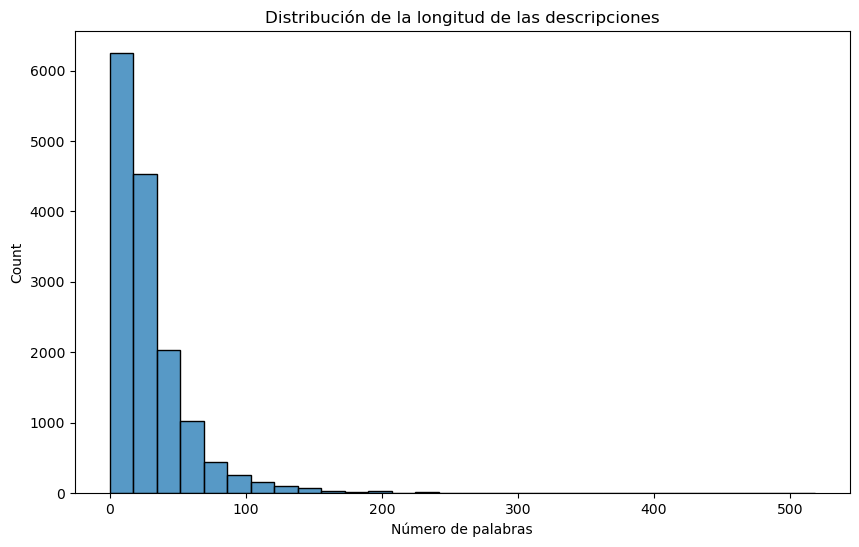

In [142]:
# Añadir columna con la longitud de cada descripción
dataset['longitud_descripcion'] = dataset['Description_limpia'].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
dataset['cantidad_palabras_no_stopwords'] = dataset['Description_limpia'].apply(lambda x: len([word for word in x.split() if word.lower() not in ENGLISH_STOP_WORDS]) if isinstance(x, str) else 0)
dataset['stopwords_eliminadas'] = dataset['Description_limpia'].apply(lambda x: ([word for word in x.split() if word.lower() in ENGLISH_STOP_WORDS]) if isinstance(x, str) else 0)



plt.figure(figsize=(10, 6))
sns.histplot(dataset['cantidad_palabras_no_stopwords'], bins=30)



plt.title('Distribución de la longitud de las descripciones')
plt.xlabel('Número de palabras')
plt.show()


In [145]:
print("Longitud máxima:", dataset['longitud_descripcion'].max())
print("Longitud mínima:", dataset['longitud_descripcion'].min())
print("Longitud promedio:", dataset['longitud_descripcion'].mean())
print("Longitud mediana:", dataset['longitud_descripcion'].median())
print("Longitud tercer cuartil:", dataset['longitud_descripcion'].quantile(0.75))


Longitud máxima: 1164
Longitud mínima: 0
Longitud promedio: 59.39998666044154
Longitud mediana: 42.0
Longitud tercer cuartil: 76.0


In [146]:
pd.set_option('display.max_colwidth', None)
dataset['descripcion_para_analisis'] = dataset['Description_limpia'].apply(lambda x: ([word for word in x.split() if word.lower() not in ENGLISH_STOP_WORDS]) if isinstance(x, str) else 0)
dataset['palabras_caracteres_eliminados']= dataset['Removed_Special_Chars']+dataset['stopwords_eliminadas'] 


(dataset[['Description', 'palabras_caracteres_eliminados', 'descripcion_para_analisis']].head(4))

,Description,palabras_caracteres_eliminados,descripcion_para_analisis
0,Nibble is a 3+ month old ball of cuteness. He is energetic and playful. I rescued a couple of cats a few months ago but could not get them neutered in time as the clinic was fully scheduled. The result was this little kitty. I do not have enough space and funds to care for more cats in my household. Looking for responsible people to take over Nibble's care.,"[', 3, +, ., I, N, H, L, T, is, of, he, is, and, of, few, but, could, not, get, them, in, as, the, was, the, was, this, do, not, have, enough, and, to, for, more, in, my, for, to, take, over]","[nibble, month, old, ball, cuteness, energetic, playful, rescued, couple, cats, months, ago, neutered, time, clinic, fully, scheduled, result, little, kitty, space, funds, care, cats, household, looking, responsible, people, nibble, care]"
1,I just found it alone yesterday near my apartment. It was shaking so I had to bring it home to provide temporary care.,"[., I, found, it, alone, my, it, was, so, had, to, it, to]","[just, yesterday, near, apartment, shaking, bring, home, provide, temporary, care]"
2,"Their pregnant mother was dumped by her irresponsible owner at the roadside near some shops in Subang Jaya. Gave birth to them at the roadside. They are all healthy and adorable puppies. Already dewormed, vaccinated and ready to go to a home. No tying or caging for long hours as guard dogs. However, it is acceptable to cage or tie for precautionary purposes. Interested to adopt pls call me.","[J, G, A, ., I, ,, T, H, S, N, their, was, by, her, at, the, some, in, to, them, at, the, they, are, all, and, already, and, to, go, to, no, or, for, as, however, it, is, to, or, for, to, call, me]","[pregnant, mother, dumped, irresponsible, owner, roadside, near, shops, subang, jaya, gave, birth, roadside, healthy, adorable, puppies, dewormed, vaccinated, ready, home, tying, caging, long, hours, guard, dogs, acceptable, cage, tie, precautionary, purposes, interested, adopt, pls]"
3,"Good guard dog, very alert, active, obedience waiting for her good master, plz call or sms for more details if you really get interested, thanks!!","[G, ,, !, very, for, her, call, or, for, more, if, you, get]","[good, guard, dog, alert, active, obedience, waiting, good, master, plz, sms, details, really, interested, thanks]"


[('home', 7849), ('dog', 4540), ('cat', 4093), ('adoption', 4025), ('good', 3563), ('adopt', 3343), ('old', 2881), ('contact', 2801), ('interested', 2784), ('looking', 2766), ('playful', 2749), ('love', 2689), ('loving', 2665), ('kitten', 2626), ('care', 2468), ('puppy', 2325), ('owner', 2275), ('healthy', 2260), ('cats', 2193), ('house', 2178)]


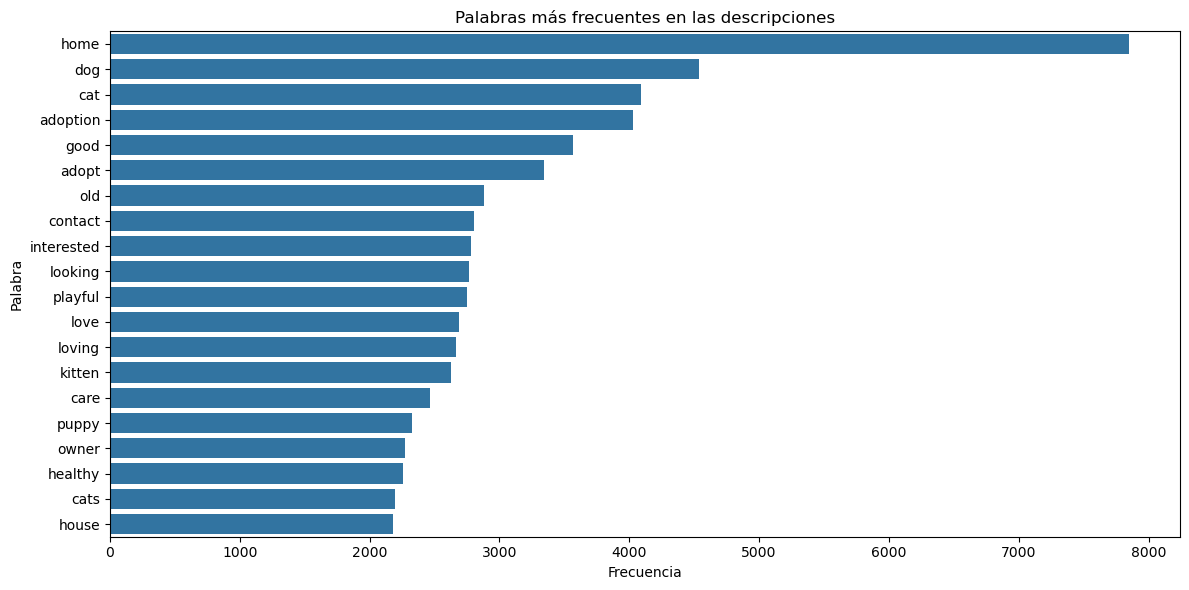

In [147]:
# Combinar todas las descripciones en una lista de palabras

# Combinar todas las palabras de la columna 'descripcion_para_analisis'
todas_palabras = list(itertools.chain.from_iterable(dataset['descripcion_para_analisis']))
palabras_comunes = Counter(todas_palabras).most_common(20)
print(palabras_comunes)



# Visualizar con un gráfico de barras
plt.figure(figsize=(12, 6))
palabras_df = pd.DataFrame(palabras_comunes, columns=['Palabra', 'Frecuencia'])
sns.barplot(x='Frecuencia', y='Palabra', data=palabras_df)
plt.title('Palabras más frecuentes en las descripciones')
plt.tight_layout()
plt.show();


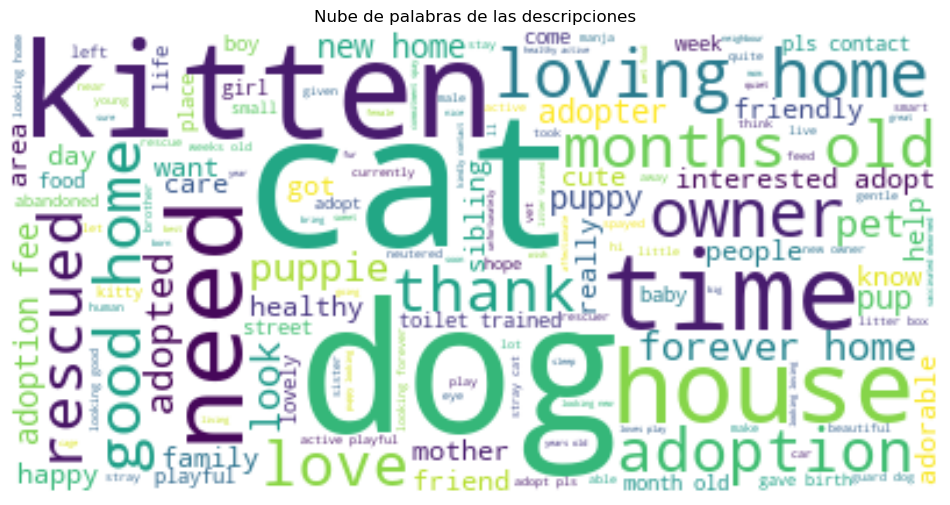

In [148]:
texto_completo = " ".join(todas_palabras)
wordcloud = WordCloud( background_color='white').generate(texto_completo)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras de las descripciones')
plt.show()